# Optativa III: Ciencia de Datos
## Semana 5 — Visualización de datos: EDA, gramática de gráficos e interactividad

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 5 · Sesiones 1 y 2**

---

### Propósito

Un dato sin visualizar es una intuición sin evidencia. En esta actividad aprenderás a **contar historias con datos**: desde el análisis exploratorio (EDA) con `matplotlib` y `seaborn` hasta gráficos **interactivos** con `Plotly`. Trabajarás con una base de datos pública real de productos de **Amazon** y, sobre todo, aprenderás a **elegir el gráfico correcto según el tipo de variable** y a **detectar visualizaciones engañosas**.

La actividad tiene dos partes:

- **PARTE A — Ejemplo guiado por el profesor.** Construiremos juntos un EDA completo con al menos 6 visualizaciones justificadas, y convertiremos gráficos estáticos en interactivos.
- **PARTE B — Tu turno.** Diseñarás visualizaciones de forma autónoma, detectarás gráficos mal hechos y construirás un mini-dashboard.

Responderás **50 preguntas ** modificando código, eligiendo gráficos e interpretando lo que muestran.

### La base de datos

`amazon.csv` — Amazon Sales Dataset (1,465 productos reales: `category`, `actual_price`, `discounted_price`, `discount_percentage`, `rating`, `rating_count`). Súbelo a Colab con el panel de archivos (icono de carpeta → subir).

### Cómo trabajar

Ejecuta cada celda con **Shift + Enter** en orden, responde las preguntas , completa los retos y, al final, guarda una copia en Drive y entrégala en Classroom.


---
# PARTE A — EDA guiado por el profesor

## Paso 0 — Preparación


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual consistente
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv("amazon.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1465, 8)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B0416836764,Producto Computers&Accessories 0,Computers&Accessories,874.0,4163.0,79.0,4.1,8922.0
1,B0490841834,Producto Car&Motorbike 1,Car&Motorbike,510.0,1021.0,50.0,4.0,13556.0
2,B0128388400,Producto Home&Kitchen 2,Home&Kitchen,1128.0,1880.0,40.0,3.2,1326.0
3,B0269299842,Producto Computers&Accessories 3,Computers&Accessories,1301.0,2711.0,52.0,3.7,5650.0
4,B0199799663,Producto Electronics 4,Electronics,4168.0,6833.0,39.0,4.1,3386.0


> **1.** ¿Cuántos productos y cuántas variables tiene el dataset? Ejecuta `df.info()` en una celda. ¿Qué variables son numéricas y cuáles categóricas?

**Respuesta:** El dataset tiene **1,465 productos** y **8 variables**, sin valores nulos.
Numéricas: `discounted_price`, `actual_price`, `discount_percentage`, `rating` y `rating_count`.
Categóricas (texto): `product_id`, `product_name` y `category`.

> **2.** El análisis exploratorio de datos (EDA) es el primer paso antes de cualquier modelo. ¿Por qué "mirar" los datos con gráficos es más revelador que solo ver una tabla de números?

**Respuesta:** La tabla da valores exactos, pero de uno en uno; el gráfico muestra la **forma
completa** de un vistazo: sesgo, concentración, huecos y valores extremos. La media de `actual_price`
es 2,565.8, pero solo el histograma revela que la mayoría de los productos cuesta bastante menos y
que unos pocos carísimos jalan ese promedio hacia arriba. Ese detalle es invisible en un número
suelto.


In [2]:
# P1: estructura del dataset
df.info()
print("\nProductos:", df.shape[0], "| Variables:", df.shape[1])
print("\nNumericas:  ", df.select_dtypes("number").columns.tolist())
print("Categoricas:", df.select_dtypes(exclude="number").columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
dtypes: float64(5), str(3)
memory usage: 91.7 KB

Productos: 1465 | Variables: 8

Numericas:   ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
Categoricas: ['product_id', 'product_name', 'category']


## La gramática de los gráficos: ¿qué gráfico usar?

Antes de graficar, hay una regla de oro: **el tipo de gráfico depende del tipo y número de variables**.

| Quieres mostrar... | Variable(s) | Gráfico recomendado |
|---|---|---|
| Distribución de UNA variable numérica | 1 numérica | Histograma, boxplot, densidad |
| Frecuencia de UNA variable categórica | 1 categórica | Barras, conteo |
| Relación entre DOS numéricas | 2 numéricas | Dispersión (scatter) |
| Numérica across categorías | 1 num + 1 cat | Boxplot, violín, barras |
| Correlación entre varias numéricas | varias numéricas | Mapa de calor (heatmap) |
| Composición de un todo | 1 categórica | Pastel (con cuidado), barras apiladas |

> **3.** Según la tabla, ¿qué gráfico usarías para mostrar la distribución de `rating`? ¿Y para comparar `actual_price` entre las distintas `category`?

**Respuesta:** `rating` es una sola variable numérica, así que su distribución se ve con un
**histograma** (o un boxplot / gráfico de densidad). Para comparar `actual_price` entre las distintas
`category` cruzo una numérica con una categórica: lo correcto es un **boxplot por categoría**, que
además de la mediana muestra la dispersión y los outliers, no solo el promedio.

> **4.** ¿Por qué NO tendría sentido usar un gráfico de dispersión (scatter) para mostrar la frecuencia de cada categoría de producto?

**Respuesta:** Un scatter necesita **dos variables numéricas** y dibuja un punto por observación para
mostrar cómo se relacionan. La frecuencia de cada categoría es un **conteo de una variable
categórica**: no hay dos ejes numéricos que cruzar, solo etiquetas y su cantidad. Eso se lee mejor
con barras, donde la longitud representa directamente el conteo.


## Visualización 1 — Distribución de una variable numérica (histograma)


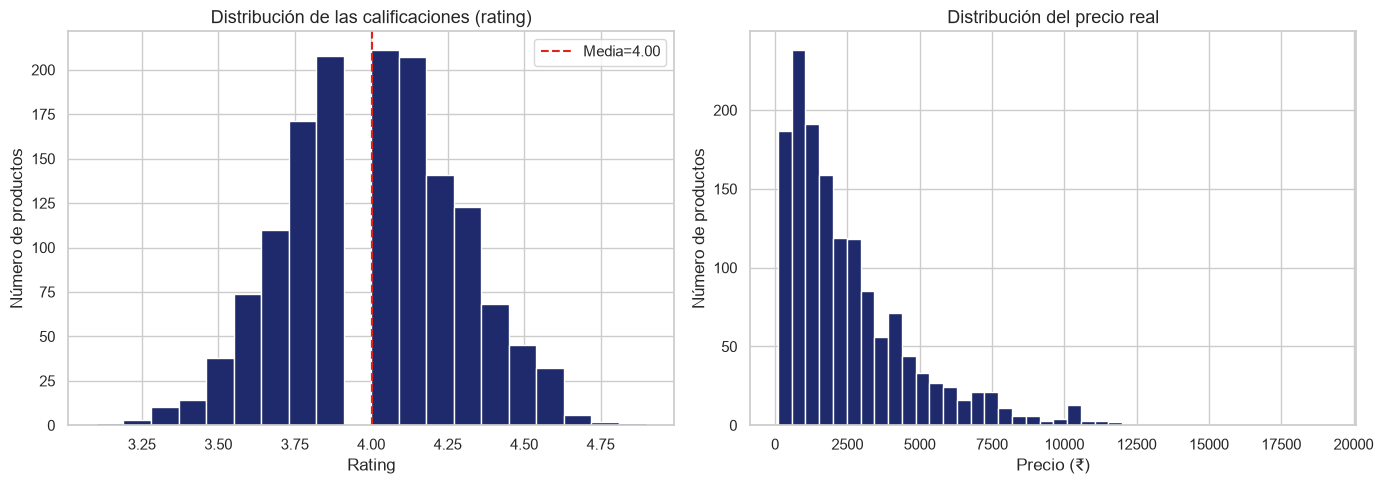

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del rating
axes[0].hist(df["rating"], bins=20, color="#1e2a6b", edgecolor="white")
axes[0].axvline(df["rating"].mean(), color="#e2231a", linestyle="--", label=f"Media={df['rating'].mean():.2f}")
axes[0].set_title("Distribución de las calificaciones (rating)")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Número de productos"); axes[0].legend()

# Histograma del precio real
axes[1].hist(df["actual_price"], bins=40, color="#1e2a6b", edgecolor="white")
axes[1].set_title("Distribución del precio real")
axes[1].set_xlabel("Precio (₹)"); axes[1].set_ylabel("Número de productos")

plt.tight_layout(); plt.show()

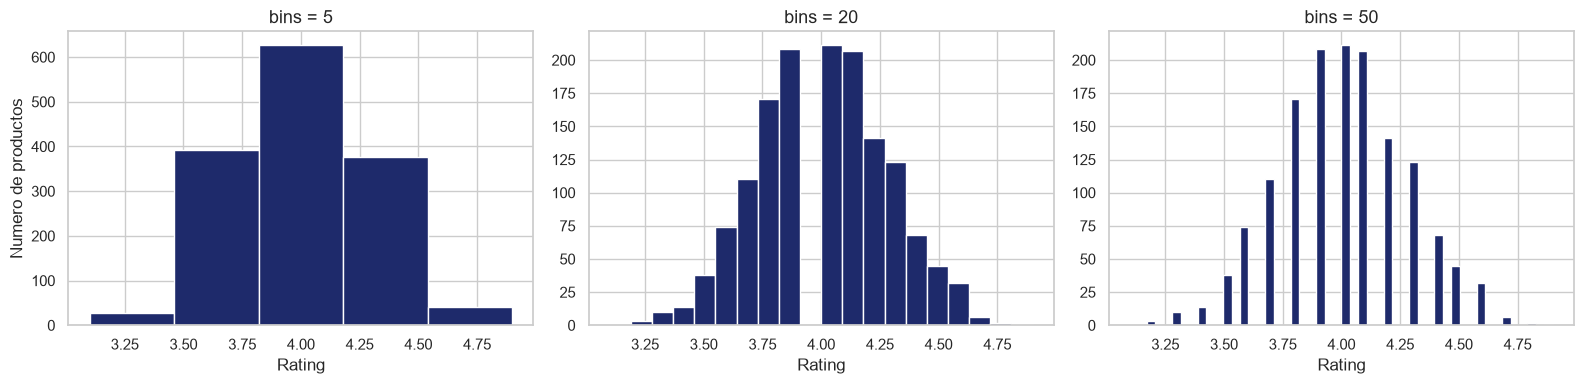

In [4]:
# P7: el mismo histograma de rating con 5, 20 y 50 bins
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, [5, 20, 50]):
    ax.hist(df["rating"], bins=b, color="#1e2a6b", edgecolor="white")
    ax.set_title(f"bins = {b}")
    ax.set_xlabel("Rating")
axes[0].set_ylabel("Numero de productos")
plt.tight_layout(); plt.show()

> **5.** Describe la forma de la distribución de `rating`: ¿es simétrica, sesgada, concentrada? ¿Alrededor de qué valor se agrupan la mayoría de los productos?

**Respuesta:** Es **casi simétrica** (asimetría = 0.04) y muy **concentrada**: media 4.004, mediana
4.0 y moda 4.0. El 72% de los productos cae entre 3.8 y 4.3, dentro de un rango total estrecho (3.1 a
4.9). Prácticamente todo el catálogo está calificado "bien".

> **6.** La distribución de `actual_price` está fuertemente sesgada a la derecha. ¿Qué significa esto sobre los precios de los productos de Amazon? ¿Por qué un histograma lo revela mejor que la media sola?

**Respuesta:** Un sesgo a la derecha significa que **la mayoría de los productos es barata** y una
minoría muy cara estira la cola: la mediana es 1,856 frente a una media de 2,565.8, con un máximo de
19,137. Si solo miro la media, creo que "el producto típico cuesta unos 2,566", y eso es falso: el
histograma muestra que el grueso está por debajo de ese valor y que el promedio está contaminado por
los extremos.

> **7.** Cambia el número de `bins` del histograma de rating a 5 y luego a 50. ¿Cómo cambia la percepción de la distribución? ¿Por qué la elección de bins puede ser engañosa?

**Respuesta:** Con 5 bins la distribución se ve como un bloque tosco y casi plano; con 50 aparecen
picos separados en 4.0, 4.1 y 4.2, porque los ratings vienen redondeados a un decimal. Los datos son
exactamente los mismos: lo único que cambia es la resolución. Pocos bins **ocultan** estructura y
demasiados convierten el ruido en "patrones", así que elegir los bins es una decisión de diseño que
puede sesgar la lectura.


## Visualización 2 — Frecuencia de una variable categórica (barras)


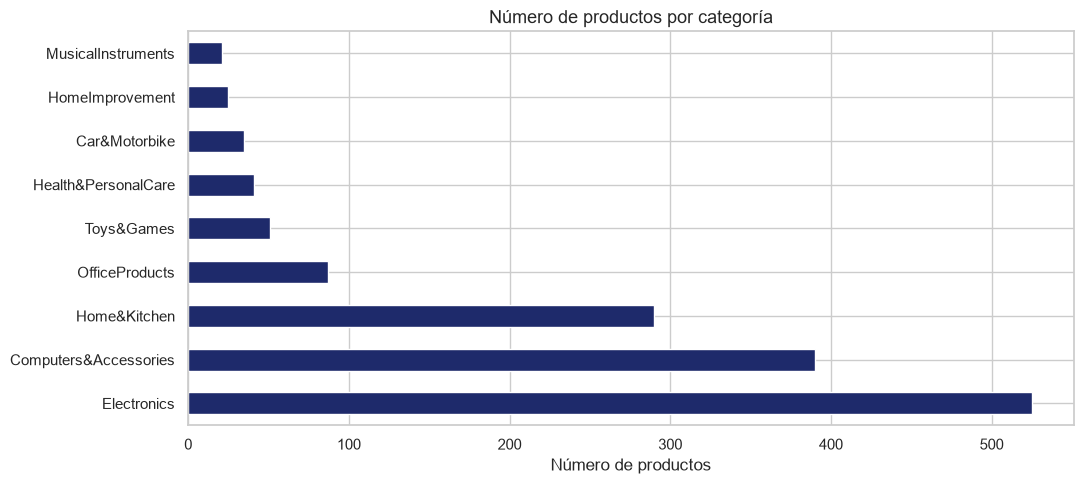

category
Electronics              525
Computers&Accessories    390
Home&Kitchen             290
OfficeProducts            87
Toys&Games                51
Health&PersonalCare       41
Car&Motorbike             35
HomeImprovement           25
MusicalInstruments        21
Name: count, dtype: int64


In [5]:
conteo = df["category"].value_counts()

plt.figure(figsize=(11, 5))
conteo.plot(kind="barh", color="#1e2a6b")
plt.title("Número de productos por categoría")
plt.xlabel("Número de productos"); plt.ylabel("")
plt.tight_layout(); plt.show()

print(conteo)

> **8.** ¿Cuál es la categoría con más productos y cuál con menos? ¿Por qué usamos barras horizontales (`barh`) en lugar de verticales aquí? (Pista: nombres largos.)

**Respuesta:** La categoría con más productos es **Electronics (525)** y la que menos tiene es
**MusicalInstruments (21)**. Uso `barh` porque los nombres son largos ("Computers&Accessories",
"Health&PersonalCare"): en barras verticales habría que rotarlos y se vuelven ilegibles, mientras que
en horizontal se leen de corrido.

> **9.** Este gráfico revela un **desbalance** de categorías. ¿Por qué es importante saber esto ANTES de sacar conclusiones sobre "todas las categorías por igual"?

**Respuesta:** El desbalance es enorme: Electronics tiene 25 veces más productos que
MusicalInstruments. Un promedio de MusicalInstruments se calcula con 21 observaciones, así que es
**mucho más inestable**: dos productos raros lo mueven entero. Sin saber esto, compararía promedios
como si todos tuvieran la misma solidez y sacaría conclusiones firmes sobre categorías que casi no
tienen datos.


## Visualización 3 — Una numérica a través de categorías (boxplot)


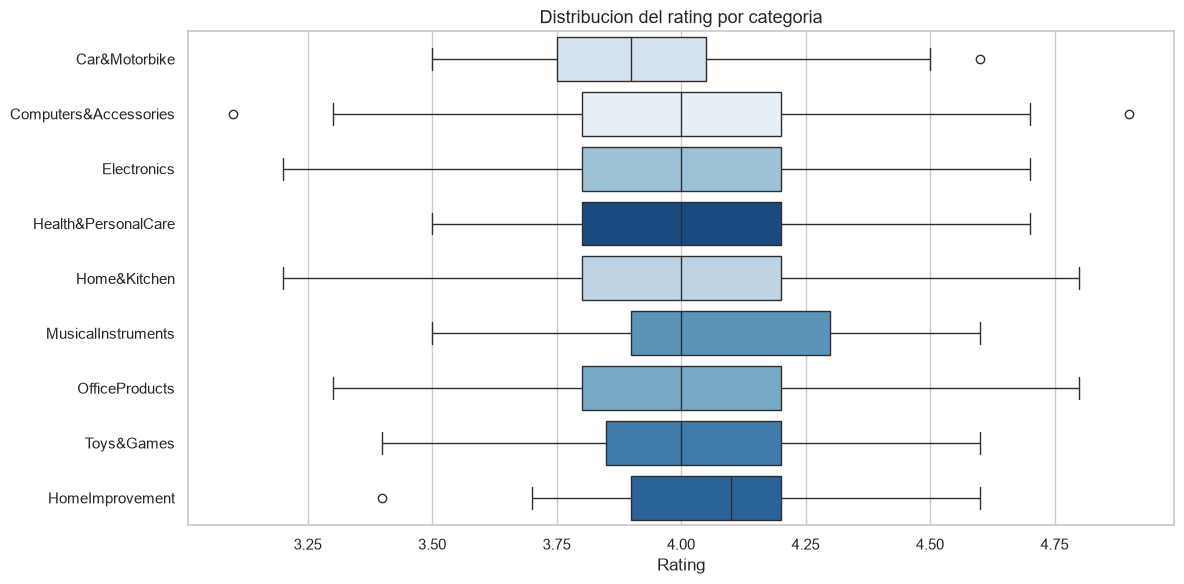

In [6]:
plt.figure(figsize=(12, 6))
orden = df.groupby("category")["rating"].median().sort_values().index
sns.boxplot(data=df, y="category", x="rating", order=orden,
            hue="category", palette="Blues", legend=False)
plt.title("Distribucion del rating por categoria")
plt.xlabel("Rating"); plt.ylabel("")
plt.tight_layout(); plt.show()

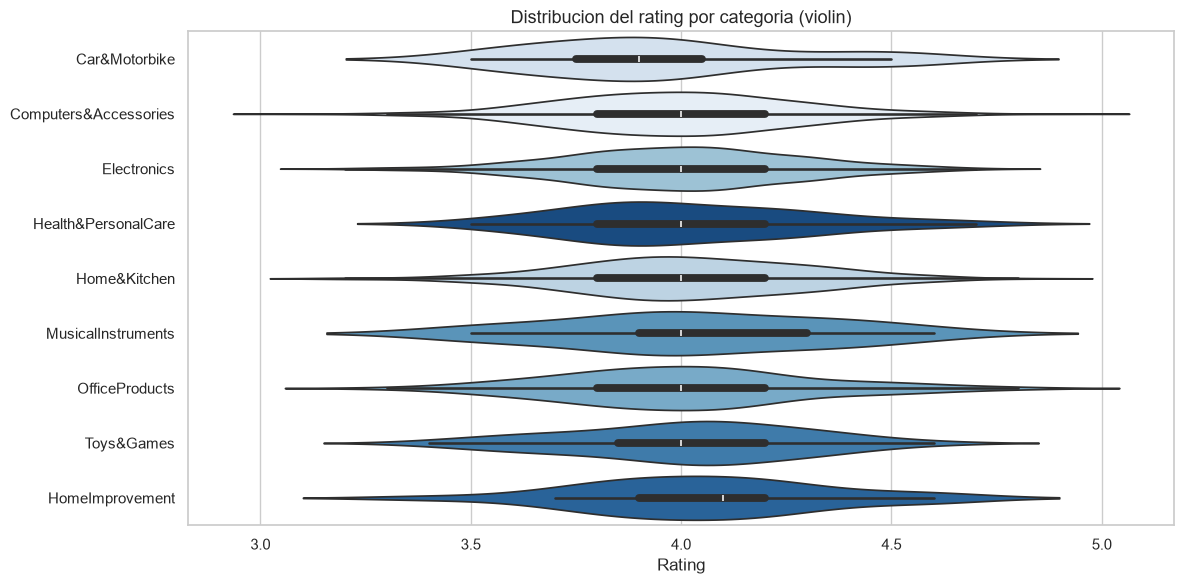

In [7]:
# P12: la misma comparacion, ahora con violin en lugar de caja
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, y="category", x="rating", order=orden,
               hue="category", palette="Blues", legend=False)
plt.title("Distribucion del rating por categoria (violin)")
plt.xlabel("Rating"); plt.ylabel("")
plt.tight_layout(); plt.show()

> **10.** ¿Qué información muestra un boxplot que un simple promedio NO muestra? (Pista: mediana, cuartiles, outliers, dispersión.)

**Respuesta:** El boxplot muestra **la forma completa del grupo**: mediana (resistente a los valores
extremos), cuartiles 1 y 3, el rango intercuartil como medida de dispersión, los bigotes y los
**outliers** uno por uno. Un promedio colapsa todo eso en un número: dos categorías con la misma
media pueden tener dispersiones totalmente distintas y el promedio no lo delata.

> **11.** Observa las cajas. ¿Las categorías tienen ratings muy distintos entre sí, o son bastante parecidos? ¿Qué te dice esto sobre la calidad percibida entre tipos de producto?

**Respuesta:** Las cajas están casi alineadas: los ratings promedio van de **3.95 (Car&Motorbike) a
4.06 (HomeImprovement)**, apenas 0.11 puntos sobre una escala de 5. La calidad percibida es
prácticamente la misma en todos los tipos de producto; lo que varía entre categorías no es el rating,
sino el precio y el descuento.

> **12.** Cambia `sns.boxplot` por `sns.violinplot` en el código y ejecuta. ¿Qué información adicional aporta el gráfico de violín sobre el boxplot?

**Respuesta:** El violín dibuja la **densidad** de los datos, no solo los cuartiles: se ve dónde se
amontonan realmente los valores. Aquí revela que dentro de la caja los ratings no se reparten parejo,
sino que forman una joroba muy marcada alrededor de 4.0 con colas delgadas. El boxplot decía "la
mitad central está entre 3.8 y 4.2"; el violín añade **cuántos productos hay en cada punto** de ese
rango.


## Visualización 4 — Relación entre dos numéricas (dispersión)


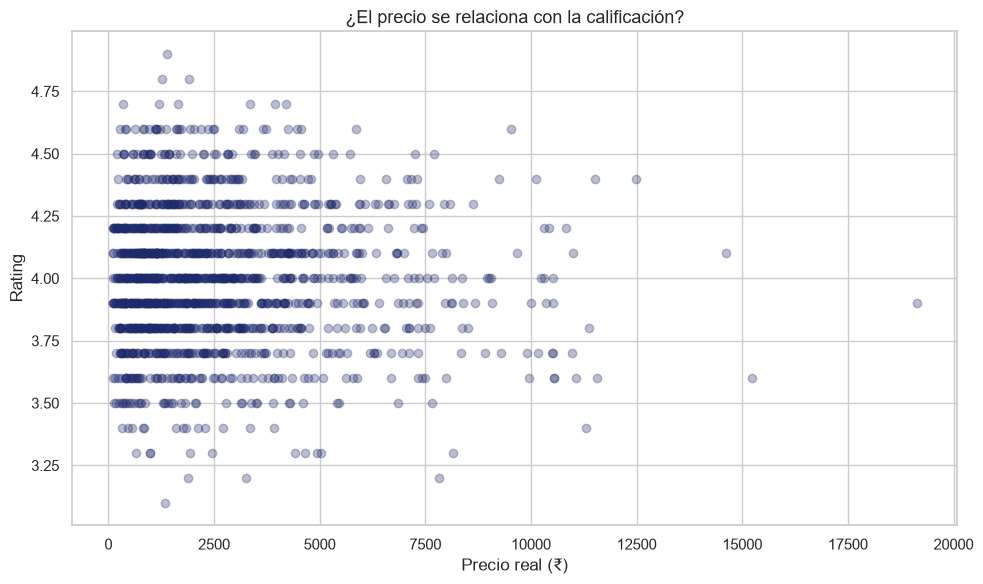

Correlación precio-rating: -0.035


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df["actual_price"], df["rating"], alpha=0.3, color="#1e2a6b")
plt.title("¿El precio se relaciona con la calificación?")
plt.xlabel("Precio real (₹)"); plt.ylabel("Rating")
plt.tight_layout(); plt.show()

print("Correlación precio-rating:", round(df["actual_price"].corr(df["rating"]), 3))

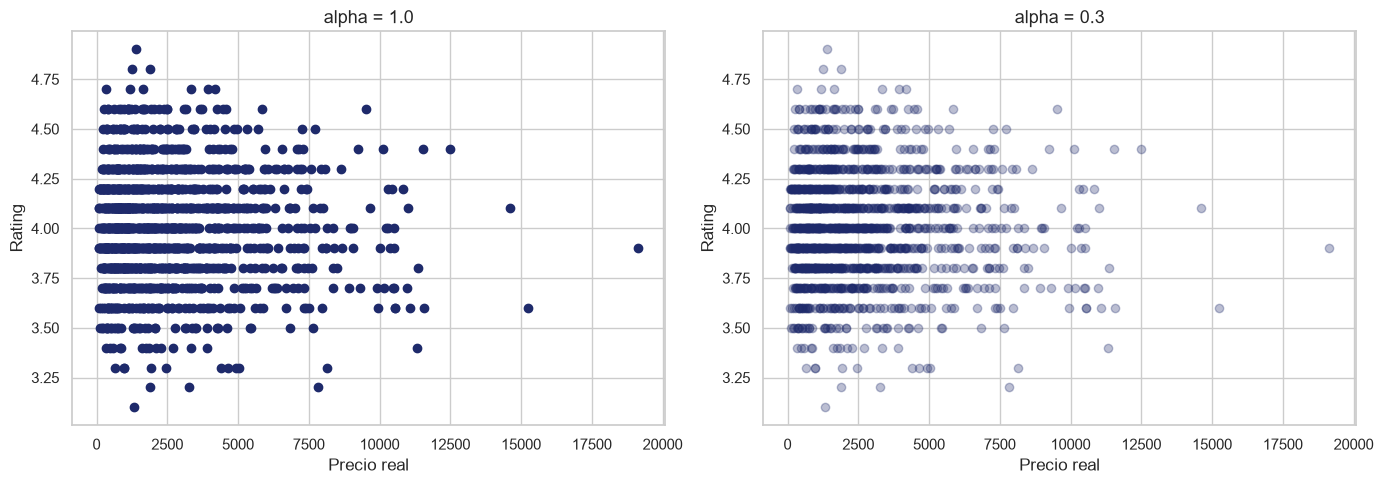

In [9]:
# P15: el efecto de la transparencia con 1,465 puntos superpuestos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, a in zip(axes, [1.0, 0.3]):
    ax.scatter(df["actual_price"], df["rating"], alpha=a, color="#1e2a6b")
    ax.set_title(f"alpha = {a}")
    ax.set_xlabel("Precio real"); ax.set_ylabel("Rating")
plt.tight_layout(); plt.show()

> **13.** Mira la nube de puntos. ¿Ves una tendencia clara (los puntos suben o bajan juntos) o una nube dispersa sin patrón? ¿Qué correlación numérica lo confirma?

**Respuesta:** Es una **nube dispersa sin patrón**: los puntos se extienden horizontalmente en una
banda entre 3.8 y 4.3 sin subir ni bajar conforme aumenta el precio. La correlación lo confirma:
**-0.035**, prácticamente cero.

> **14.** Este gráfico responde una pregunta de negocio: "¿los productos más caros están mejor calificados?". Según lo que ves, ¿cuál es la respuesta? ¿Desmiente la creencia de que "lo caro es mejor"?

**Respuesta:** La respuesta es **no**: los productos más caros no están mejor calificados. Con una
correlación de -0.035, el precio no aporta ninguna información sobre el rating. El gráfico desmiente
la creencia de que "lo caro es mejor", al menos en términos de la **satisfacción que reportan los
compradores** de este catálogo.

> **15.** El gráfico usa `alpha=0.3` (transparencia). ¿Por qué es útil la transparencia cuando hay 1,465 puntos superpuestos? Cámbialo a `alpha=1.0` y observa la diferencia.

**Respuesta:** Con `alpha=1.0` los puntos opacos se tapan entre sí y toda la zona del rating 4.0 se
ve como una mancha sólida: no distingo si ahí hay 50 o 500 productos. La transparencia hace que las
regiones densas se vean **más oscuras por acumulación**, de modo que la intensidad pasa a codificar
cuántos productos hay en cada zona. Es la forma de recuperar la información que se pierde por
superposición.


## Visualización 5 — Correlación entre varias numéricas (heatmap)


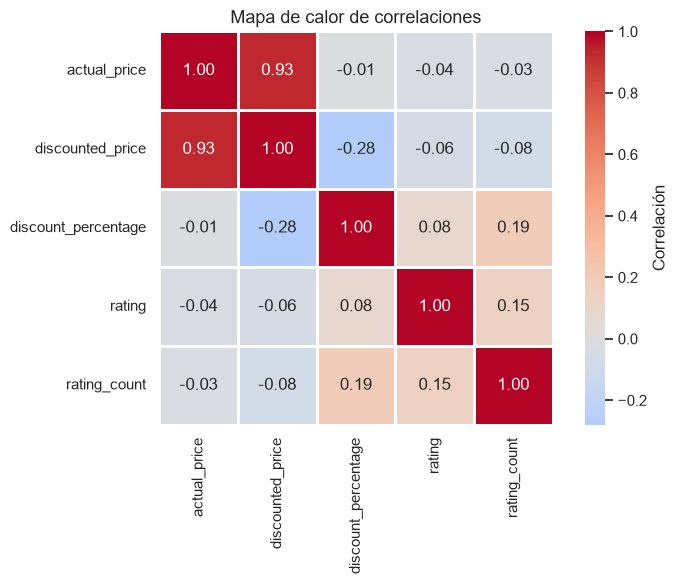

In [10]:
numericas = ["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]
matriz = df[numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=1, cbar_kws={"label": "Correlación"})
plt.title("Mapa de calor de correlaciones")
plt.tight_layout(); plt.show()

> **16.** ¿Cuál es el par de variables con la correlación más fuerte (más cercana a 1)? ¿Tiene sentido lógico?

**Respuesta:** El par más fuerte es **`actual_price` con `discounted_price`: 0.93**. Tiene todo el
sentido lógico, porque el precio con descuento **se calcula a partir** del precio original: un
producto caro sigue siendo caro después de la rebaja. No es un hallazgo, es una relación mecánica.

> **17.** ¿Por qué el mapa de calor es una forma más eficiente de ver correlaciones que hacer 10 gráficos de dispersión por separado?

**Respuesta:** El heatmap muestra las **10 correlaciones de un vistazo** en una sola imagen y permite
comparar intensidades por color sin leer número por número. Con 10 scatters separados tendría que
recordar la forma de cada uno para compararlos; aquí detecto en dos segundos cuáles pares valen la
pena mirar en detalle. El heatmap sirve para **localizar**; el scatter, para **inspeccionar**.

> **18.** El color rojo indica correlación positiva y el azul negativa. ¿Por qué elegir una paleta divergente (dos colores desde el centro) es correcto para correlaciones, en lugar de una paleta de un solo color?

**Respuesta:** Porque la correlación tiene un **punto medio con significado propio, el cero**, y dos
direcciones cualitativamente opuestas. Una paleta divergente centrada en 0 hace que el signo se lea
por el color y la fuerza por la intensidad. Con una paleta de un solo tono, -0.9 y +0.9 quedarían en
extremos opuestos de la escala y el cero caería a media rampa sin verse neutro, lo que confunde la
lectura.


## Visualización 6 — Composición y comparación (barras agrupadas)


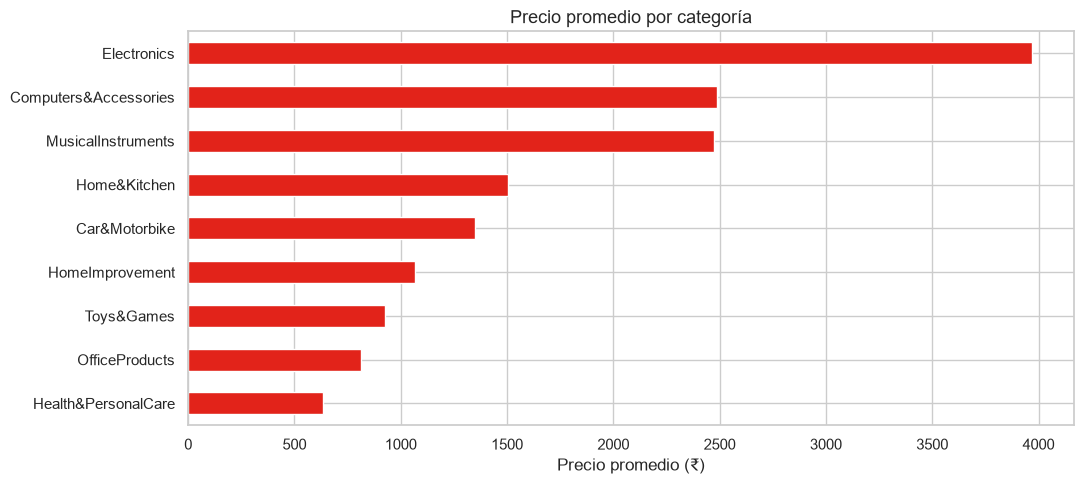

category
Health&PersonalCare       634.0
OfficeProducts            814.0
Toys&Games                926.0
HomeImprovement          1068.0
Car&Motorbike            1348.0
Home&Kitchen             1505.0
MusicalInstruments       2475.0
Computers&Accessories    2485.0
Electronics              3968.0
Name: actual_price, dtype: float64


In [11]:
# Precio promedio por categoria
precio_cat = df.groupby("category")["actual_price"].mean().sort_values()

plt.figure(figsize=(11, 5))
precio_cat.plot(kind="barh", color="#e2231a")
plt.title("Precio promedio por categoría")
plt.xlabel("Precio promedio (₹)"); plt.ylabel("")
plt.tight_layout(); plt.show()

print(precio_cat.round(0))

> **19.** ¿Qué categoría tiene el precio promedio más alto y cuál el más bajo? ¿Tiene sentido con lo que sabes de esos productos?

**Respuesta:** El precio promedio más alto es **Electronics (3,968)** y el más bajo
**Health&PersonalCare (634)**: seis veces de diferencia. Es coherente, porque electrónica incluye
pantallas y equipos, mientras que cuidado personal son consumibles de bajo precio unitario.

> **20.** Ya tienes 6 visualizaciones. Para cada una, escribe en UNA frase qué pregunta responde. Este ejercicio de **justificar cada gráfico** es la esencia de un buen EDA: nunca grafiques "porque sí".

**Respuesta:** Qué pregunta responde cada visualización:

| # | Gráfico | Pregunta que responde |
|---|---|---|
| 1 | Histogramas | ¿Cómo se reparten las calificaciones y los precios del catálogo? |
| 2 | Barras horizontales | ¿Qué tan representada está cada categoría? |
| 3 | Boxplot por categoría | ¿Hay categorías mejor calificadas que otras? |
| 4 | Dispersión | ¿Los productos más caros se califican mejor? |
| 5 | Heatmap | ¿Qué variables numéricas se mueven juntas? |
| 6 | Barras de precio | ¿Qué categorías son caras y cuáles baratas? |


### Reto 1 — Tu séptima visualización

Crea una visualización que muestre la relación entre `discount_percentage` y `rating_count` (¿los productos con más descuento tienen más reseñas?). Elige el gráfico adecuado y justifica tu elección.


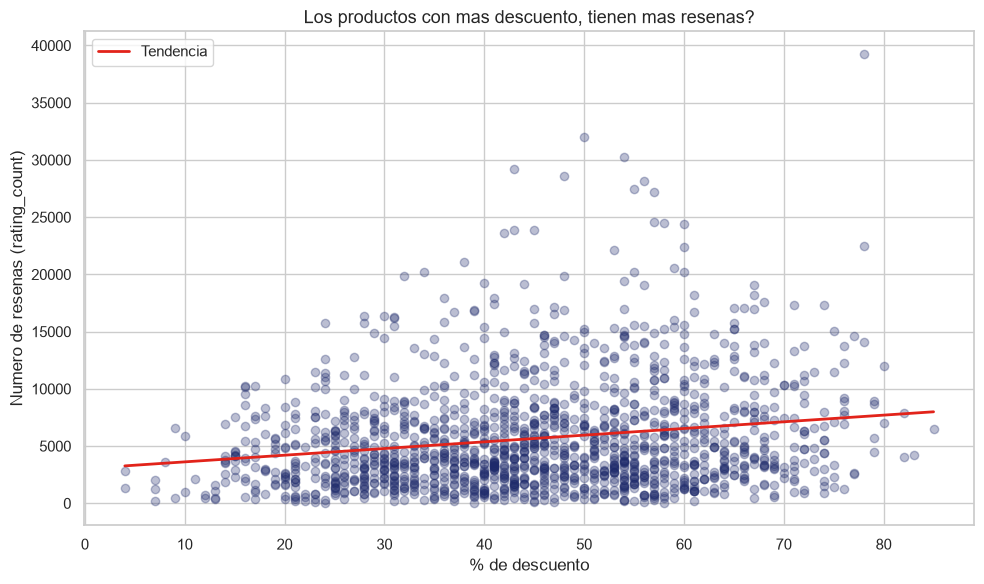

Correlacion descuento-resenas: 0.191


In [12]:
# RETO 1: relacion entre discount_percentage y rating_count.
# Son dos variables numericas -> el grafico correcto es la dispersion.
plt.figure(figsize=(10, 6))
plt.scatter(df["discount_percentage"], df["rating_count"], alpha=0.3, color="#1e2a6b")

# Linea de tendencia para leer la direccion de la relacion sin adivinar
m, b = np.polyfit(df["discount_percentage"], df["rating_count"], 1)
x = np.linspace(df["discount_percentage"].min(), df["discount_percentage"].max(), 50)
plt.plot(x, m * x + b, color="#e2231a", linewidth=2, label="Tendencia")

plt.title("Los productos con mas descuento, tienen mas resenas?")
plt.xlabel("% de descuento"); plt.ylabel("Numero de resenas (rating_count)")
plt.legend(); plt.tight_layout(); plt.show()

print("Correlacion descuento-resenas:",
      round(df["discount_percentage"].corr(df["rating_count"]), 3))

> **21.** ¿Qué gráfico elegiste y por qué? ¿Qué patrón observas entre descuento y número de reseñas?

**Respuesta:** Elegí un **gráfico de dispersión**, porque cruzo dos variables numéricas
(`discount_percentage` y `rating_count`) y quiero ver si se mueven juntas; le añadí una línea de
tendencia para leer la dirección sin adivinar. El patrón es una **relación positiva pero débil:
correlación 0.191**. La línea sube ligeramente, así que los productos con más descuento tienden a
tener algo más de reseñas, pero la dispersión es tan grande que el descuento no sirve para predecir
cuántas reseñas tendrá un producto. Es una señal real, no una regla.


---
# PARTE A (cont.) — Visualización interactiva con Plotly

Los gráficos estáticos son excelentes para reportes, pero los **interactivos** permiten explorar: hacer zoom, ver valores al pasar el cursor (hover), filtrar. Usaremos **Plotly**.

## Paso 7 — De estático a interactivo


In [13]:
import plotly.express as px

# El mismo scatter de antes, pero interactivo
fig = px.scatter(df, x="actual_price", y="rating",
                 color="category",
                 hover_data=["product_name", "discount_percentage"],
                 title="Precio vs Rating (interactivo — pasa el cursor sobre los puntos)")
fig.update_layout(height=550)
fig.show()

> **22.** Pasa el cursor sobre varios puntos. ¿Qué información aparece en el hover? ¿Por qué esto es más útil que un scatter estático para explorar productos individuales?

**Respuesta:** El hover muestra el **nombre del producto**, su precio, su rating y el porcentaje de
descuento del punto exacto sobre el que está el cursor. En el scatter estático, un punto raro es solo
una coordenada: veo que existe un producto de 19,137 con rating 3.9, pero no sé cuál es. Con hover
paso del patrón general al **caso individual** sin escribir una línea de código ni volver al
DataFrame.

> **23.** Usa la leyenda de la derecha: haz clic en una categoría para ocultarla. ¿Cómo ayuda esta interactividad a analizar categoría por categoría?

**Respuesta:** Al hacer clic en la leyenda, esa categoría desaparece y las demás se quedan **en la
misma escala**, así que puedo aislar Electronics o comparar dos categorías sin que las otras mil
observaciones tapen la zona. Es la manera rápida de hacer el análisis por subgrupos que en matplotlib
exigiría filtrar el DataFrame y regenerar la figura cada vez.

> **24.** ¿En qué situación preferirías un gráfico ESTÁTICO (matplotlib) sobre uno interactivo (Plotly)? Piensa en reportes impresos vs exploración en pantalla.

**Respuesta:** Prefiero el estático cuando el gráfico **va a viajar**: un reporte impreso, un PDF, una
diapositiva o un artículo, donde nadie va a pasar el cursor y lo único que cuenta es que el mensaje se
entienda de golpe. También cuando el mensaje ya está cerrado y no quiero que la audiencia se distraiga
explorando. El interactivo es para **explorar en pantalla**: cuando aún busco el hallazgo, o cuando
entrego un dashboard que otros van a consultar.


## Paso 8 — Gráfico de barras interactivo


In [14]:
precio_cat = df.groupby("category")["actual_price"].mean().sort_values().reset_index()

fig = px.bar(precio_cat, x="actual_price", y="category", orientation="h",
             title="Precio promedio por categoría (interactivo)",
             labels={"actual_price": "Precio promedio (₹)", "category": ""},
             color="actual_price", color_continuous_scale="Blues")
fig.update_layout(height=450)
fig.show()

> **25.** ¿Qué ventaja tiene poder ver el valor exacto al pasar el cursor sobre cada barra, en lugar de tener que estimarlo del eje?

**Respuesta:** Porque estimar a partir del eje siempre introduce **error de lectura**: mirando la
barra de Electronics diría "como 4,000", pero el valor real es 3,968.4. Cuando las diferencias son
pequeñas (OfficeProducts 813.6 frente a Toys&Games 926.2), el ojo no distingue barras casi iguales y
el hover resuelve la ambigüedad al instante. Además el gráfico conserva su limpieza: no hace falta
imprimir etiquetas sobre cada barra para que el dato exacto esté disponible.


### Reto 2 — Histograma interactivo

Crea un histograma interactivo de `rating` con Plotly usando `px.histogram(df, x="rating", nbins=20)`. Añade `color="category"` para ver la composición.


In [15]:
# RETO 2: histograma interactivo con Plotly
fig = px.histogram(df, x="rating", nbins=20, color="category",
                   title="Distribucion de rating por categoria (interactivo)",
                   labels={"rating": "Rating"})
fig.update_layout(height=500, bargap=0.05, yaxis_title="Numero de productos")
fig.show()

> **26.** Con el color por categoría, ¿puedes ver si alguna categoría domina cierto rango de ratings? ¿Qué aporta el color aquí?

**Respuesta:** Sí: se ve que **Electronics y Computers&Accessories dominan casi todos los rangos** de
rating, simplemente porque aportan 915 de los 1,465 productos. Ninguna categoría monopoliza un rango
de calificación en particular; todas se apilan alrededor de 4.0. El color aporta la **composición
interna** de cada barra: el histograma simple decía cuántos productos hay en cada rango, y el color
añade de dónde vienen. De paso, el desbalance entre categorías queda visible en la misma figura.


---
# PARTE B — Buenas prácticas y detección de gráficos engañosos

Un gráfico puede **mentir** sin falsear un solo dato, solo con malas decisiones de diseño. Aprender a detectarlo es tan importante como saber graficar.

## Paso 9 — El error del eje Y truncado (escala engañosa)


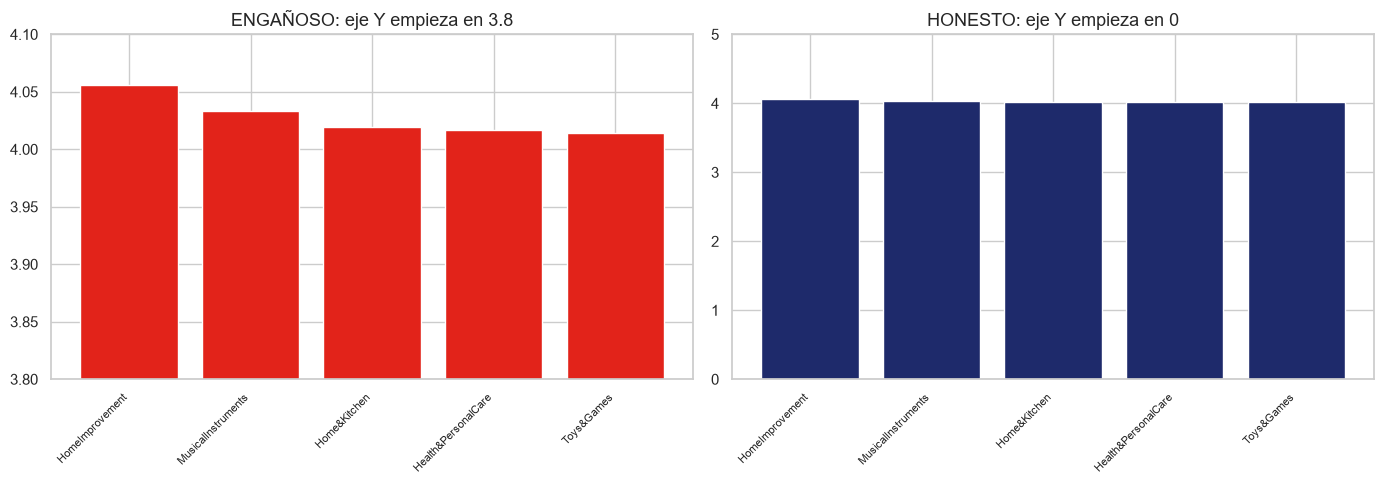

In [16]:
# Diferencias reales de rating entre categorias (son pequeñas)
rating_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ENGAÑOSO: eje Y truncado (empieza en 3.8, exagera diferencias)
axes[0].bar(range(len(rating_cat)), rating_cat.values, color="#e2231a")
axes[0].set_ylim(3.8, 4.1)
axes[0].set_title("ENGAÑOSO: eje Y empieza en 3.8")
axes[0].set_xticks(range(len(rating_cat)))
axes[0].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=8)

# HONESTO: eje Y empieza en 0
axes[1].bar(range(len(rating_cat)), rating_cat.values, color="#1e2a6b")
axes[1].set_ylim(0, 5)
axes[1].set_title("HONESTO: eje Y empieza en 0")
axes[1].set_xticks(range(len(rating_cat)))
axes[1].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

> **27.** Compara los dos gráficos. Muestran EXACTAMENTE los mismos datos. ¿Por qué el de la izquierda hace parecer que las diferencias entre categorías son enormes?

**Respuesta:** Porque el eje izquierdo va de **3.8 a 4.1**, es decir, solo 0.3 puntos de recorrido.
Una diferencia real de 0.05 puntos ocupa así un sexto de la altura del gráfico y parece enorme, cuando
en una escala de 0 a 5 sería invisible. El ojo compara **longitudes de barra**, y al truncar el eje
esas longitudes dejan de ser proporcionales a los valores: una barra del doble de alta ya no significa
el doble de rating.

> **28.** ¿Cuál es la regla de buenas prácticas para el eje Y en un gráfico de barras? ¿Por qué truncar el eje es una de las formas más comunes de mentir con estadísticas?

**Respuesta:** La regla es que en un gráfico de barras el **eje Y debe empezar en cero**, porque la
barra codifica la magnitud mediante su longitud y esa longitud solo es honesta si parte del origen. Es
una de las mentiras estadísticas más comunes porque **no falsea ningún dato**: los números son
correctos, las barras son correctas, y aun así la impresión visual es falsa. Como el lector confía en
la imagen y casi nunca revisa el eje, el engaño pasa desapercibido.

> **29.** ¿Existe algún caso donde truncar el eje Y sea legítimo? (Pista: gráficos de líneas de series temporales con variaciones pequeñas.) Investiga y argumenta.

**Respuesta:** Sí, es legítimo en **gráficos de línea de series temporales**, donde lo que importa es
la variación y no la magnitud absoluta: la temperatura corporal a lo largo de un día o el precio de
una acción no se grafican desde cero, porque el rango útil es estrecho y forzar el origen aplanaría la
serie hasta volverla inútil. La diferencia está en que la línea codifica **posición**, no longitud
desde un origen, así que no promete proporcionalidad. Aun así, la buena práctica es rotular la escala
con claridad y, si el recorte es fuerte, indicarlo de forma explícita.


## Paso 10 — Chartjunk (basura visual)


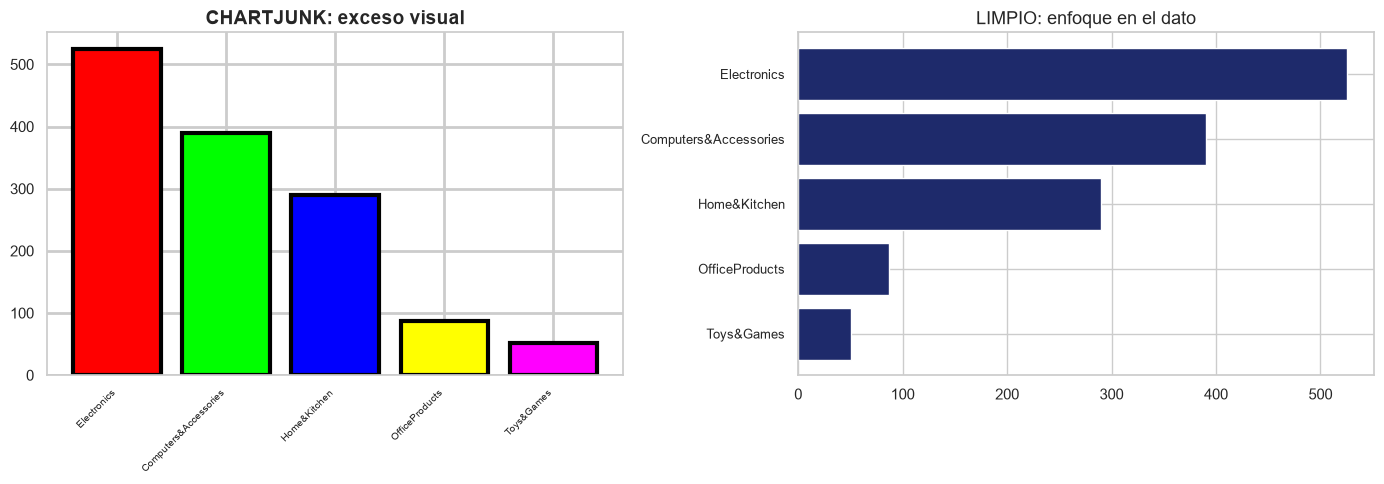

In [17]:
# Ejemplo de lo que NO se debe hacer vs version limpia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos = df["category"].value_counts().head(5)

# CHARTJUNK: colores chillones, sombras, sin orden, 3D simulado
colores_feos = ["#ff0000", "#00ff00", "#0000ff", "#ffff00", "#ff00ff"]
axes[0].bar(range(len(datos)), datos.values, color=colores_feos, edgecolor="black", linewidth=3)
axes[0].set_title("CHARTJUNK: exceso visual", fontsize=14, fontweight="bold")
axes[0].set_xticks(range(len(datos)))
axes[0].set_xticklabels(datos.index, rotation=45, ha="right", fontsize=7)
axes[0].grid(True, linewidth=2)

# LIMPIO: un color, ordenado, sin adornos
axes[1].barh(range(len(datos)), datos.values, color="#1e2a6b")
axes[1].set_yticks(range(len(datos)))
axes[1].set_yticklabels(datos.index, fontsize=9)
axes[1].set_title("LIMPIO: enfoque en el dato")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

> **30.** ¿Qué elementos hacen "ruidoso" al gráfico de la izquierda? Lista al menos tres problemas de diseño.

**Respuesta:** Problemas de diseño del gráfico de la izquierda:

1. **Paleta arcoíris arbitraria**: cinco colores saturados para una sola serie, donde el color no
   codifica ninguna información y compite con el dato.
2. **Bordes negros gruesos y cuadrícula pesada**, que añaden tinta sin añadir información y cansan la
   vista.
3. **Categorías sin ordenar y etiquetas rotadas a 7 puntos**, ilegibles y sin jerarquía: el lector no
   puede rankear de un vistazo.
4. **Faltan las etiquetas de los ejes**: no se sabe qué mide la altura de las barras.

> **31.** Define "chartjunk" con tus palabras. ¿Por qué usar un solo color (o pocos) suele comunicar mejor que un arcoíris?

**Respuesta:** Chartjunk es **todo elemento visual de un gráfico que no aporta información**: adornos,
sombras, texturas, 3D falso, colores decorativos, rejillas gruesas. Ocupa atención sin pagar nada a
cambio. Un solo color funciona mejor porque **el color deja de ser ruido y queda disponible como
herramienta**: si todo es azul menos una barra, esa barra es el mensaje. Con un arcoíris, el lector
busca un significado en los colores, no lo encuentra, y el mensaje se diluye.

> **32.** El "data-ink ratio" (proporción de tinta que representa datos vs adornos) debe ser alto. ¿Qué adornos eliminarías del gráfico feo para mejorarlo?

**Respuesta:** Quitaría los cinco colores (dejaría uno), los bordes negros gruesos, la cuadrícula de
grosor 2 y el título en negrita de 14 puntos que compite con los datos. Añadiría orden por magnitud y
orientación horizontal para que las etiquetas se lean. El resultado es que casi toda la tinta pasa a
representar datos, que es justo lo que pide un **data-ink ratio** alto.


## Paso 11 — El problema del gráfico de pastel


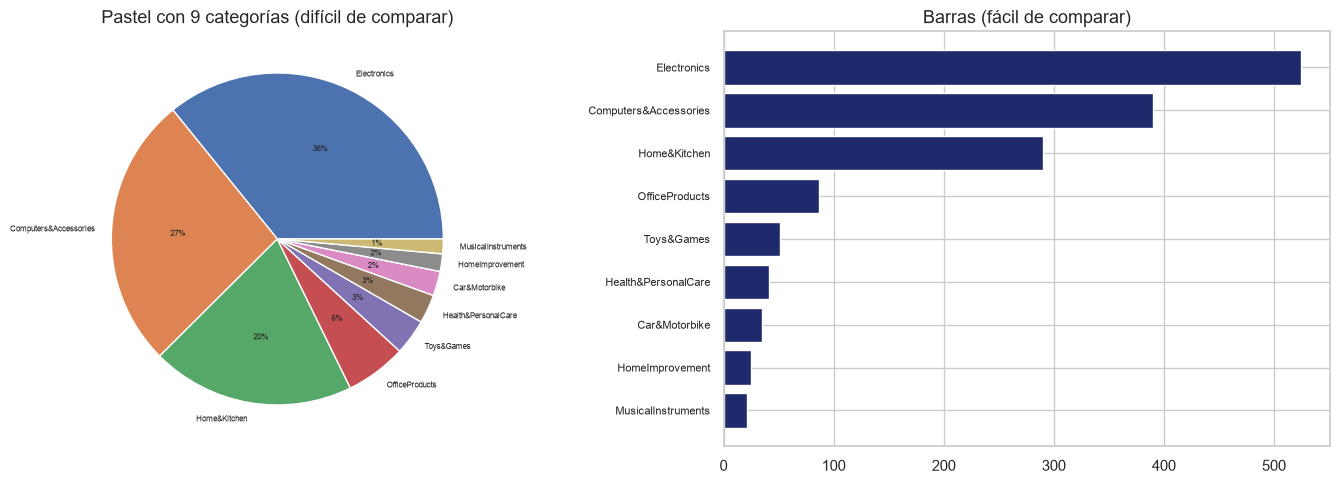

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos = df["category"].value_counts()

# Pastel con muchas categorias (dificil de leer)
axes[0].pie(datos.values, labels=datos.index, autopct="%1.0f%%", textprops={"fontsize": 6})
axes[0].set_title("Pastel con 9 categorías (difícil de comparar)")

# Barras (facil de comparar)
axes[1].barh(range(len(datos)), datos.values, color="#1e2a6b")
axes[1].set_yticks(range(len(datos))); axes[1].set_yticklabels(datos.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Barras (fácil de comparar)")

plt.tight_layout(); plt.show()

> **33.** ¿Por qué es difícil comparar visualmente las porciones de un pastel con 9 categorías? ¿Qué hace el ojo humano mejor: comparar ángulos o comparar longitudes?

**Respuesta:** Porque las porciones se comparan por **ángulo y área**, y el ojo humano es malo en
ambas cosas: con 9 categorías, varias quedan como rebanadas delgadas casi idénticas y es imposible
decir cuál es mayor sin leer el porcentaje impreso (y si un gráfico necesita números para entenderse,
el gráfico falló). En cambio, el ojo es **muy bueno comparando longitudes alineadas sobre un eje
común**, que es exactamente lo que hacen las barras: por eso la versión derecha se lee al instante.

> **34.** ¿En qué caso SÍ es aceptable un gráfico de pastel? (Pista: pocas categorías, mostrar una parte de un todo.)

**Respuesta:** Es aceptable cuando hay **dos o tres categorías** y lo que quiero comunicar es
explícitamente una **parte de un todo** que suma 100%: "el 62% del catálogo es electrónica y cómputo,
el 38% todo lo demás". Ahí la comparación es gruesa, la noción de "todo" importa más que el ranking y
el pastel la transmite de inmediato. Para rankear, o con muchas categorías, siempre barras.


### Reto 3 — Corrige un gráfico engañoso

Toma el precio promedio por categoría y crea DOS versiones: una engañosa (eje truncado) y una honesta. Explica qué cambió.


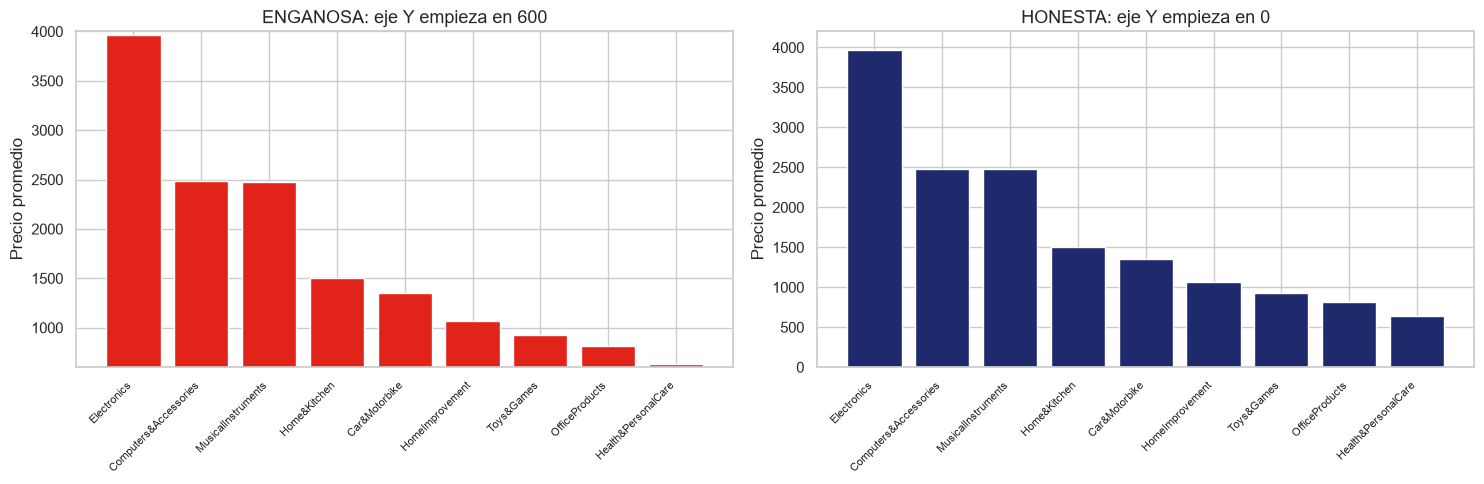

Relacion real: Electronics cuesta 6.3 veces lo que Health&PersonalCare


In [19]:
# RETO 3: el MISMO dato (precio promedio por categoria) en dos versiones
precio_cat = df.groupby("category")["actual_price"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ENGANOSA: el eje arranca justo debajo de la categoria mas barata
axes[0].bar(range(len(precio_cat)), precio_cat.values, color="#e2231a")
axes[0].set_ylim(600, 4000)
axes[0].set_title("ENGANOSA: eje Y empieza en 600")
axes[0].set_ylabel("Precio promedio")

# HONESTA: el eje arranca en cero
axes[1].bar(range(len(precio_cat)), precio_cat.values, color="#1e2a6b")
axes[1].set_ylim(0, 4200)
axes[1].set_title("HONESTA: eje Y empieza en 0")
axes[1].set_ylabel("Precio promedio")

for ax in axes:
    ax.set_xticks(range(len(precio_cat)))
    ax.set_xticklabels(precio_cat.index, rotation=45, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

print("Relacion real: Electronics cuesta",
      round(precio_cat.max() / precio_cat.min(), 1),
      "veces lo que Health&PersonalCare")

> **35.** ¿Qué decisión de diseño hiciste para la versión honesta? ¿Por qué la versión engañosa podría usarse para manipular una decisión de negocio?

**Respuesta:** Para la versión honesta puse el **eje en 0** y lo extendí un poco por encima del valor
máximo, de modo que la longitud de cada barra sea proporcional a su precio promedio: se ve que
Electronics cuesta unas 6 veces lo que Health&PersonalCare, que es la relación real. En la versión
engañosa arranqué el eje en 600, justo debajo de la categoría más barata, y entonces
Health&PersonalCare se reduce a una barra minúscula: aparenta ser **20 o 30 veces** más barata.

Esa versión serviría para manipular una decisión de negocio real: un proveedor que quisiera justificar
un aumento de precio en Health&PersonalCare mostraría el gráfico truncado para argumentar que "esa
categoría está absurdamente por debajo del resto del catálogo" y que hay un margen enorme para subir.
Los datos son verdaderos; la conclusión que induce, no.


## Paso 12 — Construyendo un mini-dashboard

Un **dashboard** combina varias visualizaciones en una sola vista para dar un panorama completo.


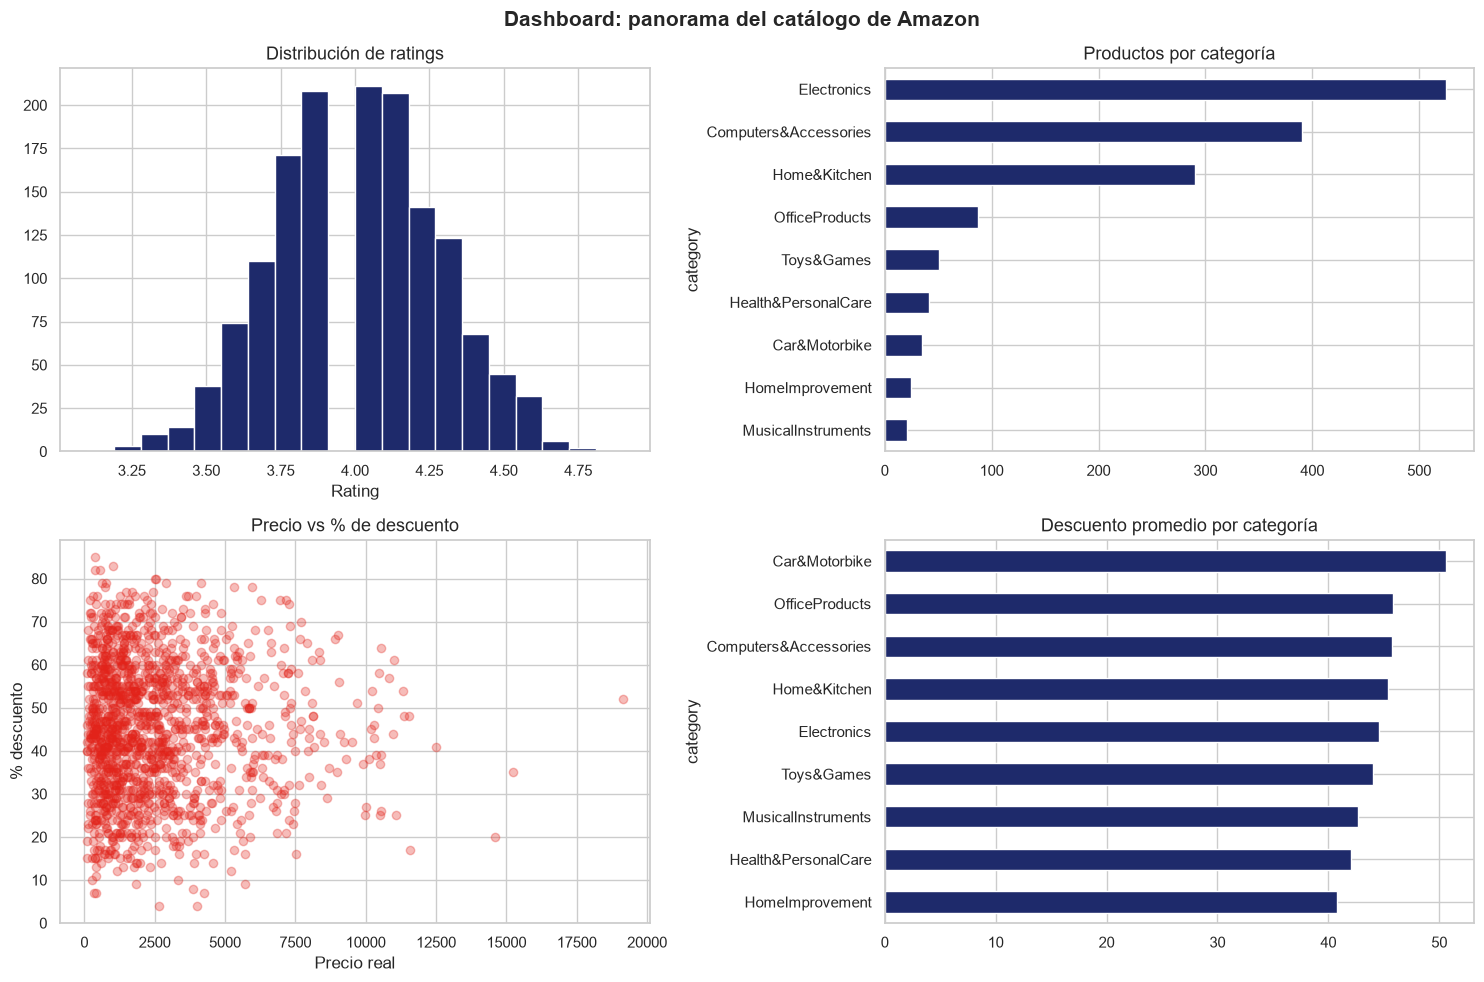

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: distribucion de rating
axes[0,0].hist(df["rating"], bins=20, color="#1e2a6b", edgecolor="white")
axes[0,0].set_title("Distribución de ratings")
axes[0,0].set_xlabel("Rating")

# Panel 2: productos por categoria
df["category"].value_counts().plot(kind="barh", ax=axes[0,1], color="#1e2a6b")
axes[0,1].set_title("Productos por categoría"); axes[0,1].invert_yaxis()

# Panel 3: precio vs descuento
axes[1,0].scatter(df["actual_price"], df["discount_percentage"], alpha=0.3, color="#e2231a")
axes[1,0].set_title("Precio vs % de descuento")
axes[1,0].set_xlabel("Precio real"); axes[1,0].set_ylabel("% descuento")

# Panel 4: descuento promedio por categoria
df.groupby("category")["discount_percentage"].mean().sort_values().plot(
    kind="barh", ax=axes[1,1], color="#1e2a6b")
axes[1,1].set_title("Descuento promedio por categoría")

plt.suptitle("Dashboard: panorama del catálogo de Amazon", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

> **36.** Un dashboard debe contar una historia coherente, no ser gráficos al azar juntos. ¿Qué historia cuentan estos 4 paneles juntos sobre el catálogo de Amazon?

**Respuesta:** Los cuatro paneles cuentan esta historia: el catálogo está **calificado de forma
uniformemente buena** (panel 1: todo se apila en 4.0) y **dominado por electrónica y cómputo** (panel
2). Donde uno esperaría diferencias no las hay (panel 3: el descuento no depende del precio, la nube
es plana), y las únicas diferencias reales entre categorías están en **la política comercial** (panel
4: el descuento promedio va de 40.8% a 50.6%). El mensaje es que el rating no distingue productos en
este catálogo; el descuento sí.

> **37.** Si tuvieras que quitar UN panel de este dashboard por redundante o poco útil, ¿cuál quitarías y por qué?

**Respuesta:** Quitaría el **panel 3 (precio vs % de descuento)**. Es el que menos aporta: la nube es
completamente plana (correlación -0.006) y su única conclusión, "no hay relación", ya queda implícita
en el panel 4, que además dice **dónde sí** cambia el descuento. Un panel que solo comunica una
ausencia ocupa un cuarto del espacio para muy poca información.

> **38.** ¿Qué panel AÑADIRÍAS para completar la historia? Justifica qué pregunta respondería.

**Respuesta:** Añadiría el **histograma de `rating_count` en escala logarítmica**. Los cuatro paneles
hablan de precio, rating y descuento, pero ninguno dice **cuánta atención recibe cada producto**, y
ese es el factor que decide si un rating es confiable: un 4.5 con 41 reseñas no vale lo mismo que un
4.5 con 39,263. Respondería "¿la calificación de estos productos está respaldada por suficientes
opiniones?", que es la pregunta que falta para cerrar la historia.


### Reto 4 — Tu propio dashboard interactivo

Usando Plotly, crea al menos DOS gráficos interactivos que juntos den un panorama del dataset (por ejemplo: dispersión precio-rating + barras de categorías). Justifica por qué elegiste esos dos.


In [21]:
# RETO 4: dos graficos interactivos que juntos dan el panorama del catalogo

# 1) Precio vs rating: responde "pagar mas garantiza un mejor producto?"
fig1 = px.scatter(df, x="actual_price", y="rating", color="category",
                  hover_data=["product_name"], opacity=0.5,
                  title="1) El precio no mueve el rating: la nube es plana",
                  labels={"actual_price": "Precio real", "rating": "Rating"})
fig1.update_layout(height=500)
fig1.show()

# 2) Descuento por categoria: responde "entonces, en que si se diferencian?"
desc_cat = (df.groupby("category")["discount_percentage"]
              .mean().sort_values().reset_index())
fig2 = px.bar(desc_cat, x="discount_percentage", y="category", orientation="h",
              color="discount_percentage", color_continuous_scale="Reds",
              title="2) Lo que si cambia entre categorias: el descuento",
              labels={"discount_percentage": "% descuento promedio", "category": ""})
fig2.update_layout(height=450)
fig2.show()

> **39.** ¿Qué dos gráficos elegiste y qué pregunta responde cada uno? ¿Por qué juntos cuentan una historia más completa que por separado?

**Respuesta:** Elegí (1) una dispersión interactiva de precio vs rating coloreada por categoría y (2)
barras interactivas del descuento promedio por categoría. La primera responde **"¿pagar más garantiza
un mejor producto?"**, y contesta que no (nube plana, correlación -0.035). La segunda responde
**"¿entonces en qué sí se diferencian las categorías?"**, y señala el descuento: de 40.8% en
HomeImprovement a 50.6% en Car&Motorbike.

Juntos cuentan más porque el primero **cierra una puerta** y el segundo **abre otra**: por separado,
el scatter deja solo un hallazgo negativo ("no hay relación") y las barras, un dato suelto. En
secuencia forman un argumento: si el rating no diferencia nada, la variable que sí discrimina entre
categorías es la agresividad comercial.

> **40.** De todas las visualizaciones que hiciste, ¿cuál te pareció que comunicaba su mensaje de forma más clara e inmediata? ¿Por qué?

**Respuesta:** El **boxplot de rating por categoría** fue el más claro e inmediato. Todas las cajas
aparecen alineadas alrededor de 4.0 y basta un vistazo para entender que las categorías no se
diferencian por calidad percibida: no hace falta leer un solo número. Además muestra al mismo tiempo
mediana, dispersión y outliers, así que comunica varias ideas con una sola forma visual.


---
# PARTE B (cont.) — Análisis autónomo e interpretación

## Paso 13 — Explora una pregunta propia


In [22]:
# Ejemplo de análisis dirigido: ¿los productos más reseñados son mejor calificados?
df["muy_reseñado"] = df["rating_count"] > df["rating_count"].median()

fig = px.box(df, x="muy_reseñado", y="rating",
             title="¿Los productos más reseñados tienen mejor rating?",
             labels={"muy_reseñado": "¿Muy reseñado?", "rating": "Rating"})
fig.show()

print("Rating promedio:")
print(df.groupby("muy_reseñado")["rating"].mean().round(3))

Rating promedio:
muy_reseñado
False    3.970
True     4.038
Name: rating, dtype: float64


> **41.** ¿Los productos más reseñados (por encima de la mediana) tienen mejor rating que los menos reseñados? ¿Qué muestra el boxplot?

**Respuesta:** Sí, pero por muy poco: los productos con más reseñas que la mediana (4,348) tienen un
rating promedio de **4.038** frente a **3.970** de los menos reseñados, apenas **0.07 puntos** de
diferencia. El boxplot lo muestra bien: las dos cajas están casi a la misma altura y se solapan casi
por completo, aunque la del grupo muy reseñado está ligeramente desplazada hacia arriba. La diferencia
existe y es consistente, pero es demasiado pequeña para tener valor práctico.

> **42.** ¿Por qué un boxplot es la elección correcta para comparar una variable numérica (rating) entre dos grupos (muy reseñado sí/no)?

**Respuesta:** Porque cruzo una variable **numérica** (rating) con una **categórica de dos niveles**
(muy reseñado sí/no), y el boxplot compara las distribuciones completas de ambos grupos lado a lado.
Ver solo los dos promedios (4.038 vs 3.970) sugeriría una diferencia limpia; el boxplot revela que las
cajas **se solapan casi por completo**, es decir, que la mayoría de los productos de un grupo tiene
ratings perfectamente alcanzables por el otro. Esa superposición es la información clave, y solo la da
un gráfico de distribución.


### Reto 5 — Investiga tu propia pregunta

Formula UNA pregunta sobre el dataset (ej. "¿las categorías caras dan más descuento?"), elige la visualización adecuada, créala e interpreta el resultado.


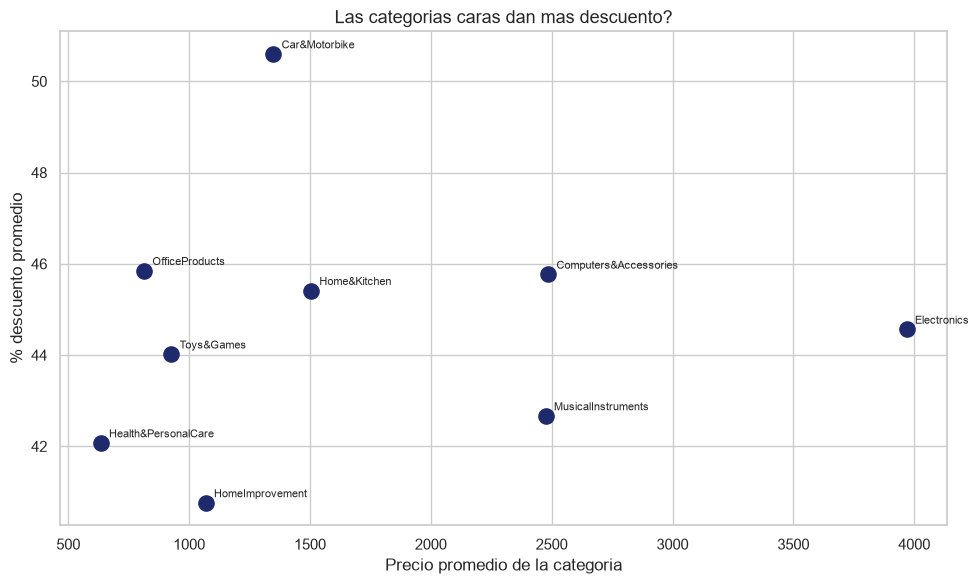

Correlacion precio-descuento (por categoria): 0.062

                       precio_promedio  descuento_promedio
category                                                  
Car&Motorbike                   1348.2                50.6
OfficeProducts                   813.6                45.9
Computers&Accessories           2485.3                45.8
Home&Kitchen                    1504.5                45.4
Electronics                     3968.4                44.6
Toys&Games                       926.2                44.0
MusicalInstruments              2475.0                42.7
Health&PersonalCare              634.1                42.1
HomeImprovement                 1068.3                40.8


In [23]:
# RETO 5
# PREGUNTA: las categorias mas caras son las que dan mas descuento?
# Cruzo dos numericas agregadas por categoria -> dispersion con etiquetas,
# porque solo hay 9 puntos y quiero poder identificar cada uno.
resumen = df.groupby("category").agg(
    precio_promedio=("actual_price", "mean"),
    descuento_promedio=("discount_percentage", "mean")
)

plt.figure(figsize=(10, 6))
plt.scatter(resumen["precio_promedio"], resumen["descuento_promedio"],
            s=120, color="#1e2a6b")
for cat in resumen.index:
    plt.annotate(cat, (resumen.loc[cat, "precio_promedio"],
                       resumen.loc[cat, "descuento_promedio"]),
                 fontsize=8, xytext=(6, 4), textcoords="offset points")

plt.title("Las categorias caras dan mas descuento?")
plt.xlabel("Precio promedio de la categoria"); plt.ylabel("% descuento promedio")
plt.tight_layout(); plt.show()

print("Correlacion precio-descuento (por categoria):",
      round(resumen["precio_promedio"].corr(resumen["descuento_promedio"]), 3))
print()
print(resumen.round(1).sort_values("descuento_promedio", ascending=False))

> **43.** ¿Qué pregunta investigaste? ¿Qué visualización elegiste y por qué era la adecuada? ¿Cuál fue tu hallazgo?

**Respuesta:** Investigué **"¿las categorías más caras son las que dan más descuento?"**, esperando
que el margen alto de la electrónica permitiera rebajas más agresivas. Elegí una **dispersión a nivel
de categoría con etiquetas**, porque cruzo dos numéricas agregadas y, al ser solo 9 puntos, puedo
identificar cada uno por nombre (con 1,465 puntos las etiquetas serían ilegibles y usaría un scatter
normal).

El hallazgo: **no hay relación**, correlación 0.062. La categoría más cara (Electronics, 3,968) da
44.6% de descuento, casi lo mismo que la más barata (Health&PersonalCare, 634) con 42.1%. El único
punto que se separa es **Car&Motorbike: 50.6% de descuento siendo una categoría barata** (1,348),
justo lo contrario de mi hipótesis.

> **44.** ¿Tu hallazgo confirmó o contradijo lo que esperabas antes de graficar? En ciencia de datos, ¿por qué es valioso cuando los datos contradicen nuestra intuición?

**Respuesta:** **Contradijo** lo que esperaba: pensaba que el precio marcaría la política de descuento
y resultó irrelevante. Que los datos contradigan la intuición es valioso porque es la única forma de
**aprender algo que no sabía de antemano**: si los datos solo confirmaran lo que ya creo, el análisis
sería decorativo. Además, una intuición falsa detectada a tiempo evita decisiones caras, y suele
señalar que la causa real es otra variable que todavía no miré (aquí, probablemente la estructura
competitiva de cada categoría, no su precio).


## Paso 14 — Cierre reflexivo


> **45.** La "gramática de gráficos" dice que el gráfico debe elegirse según el tipo de dato. Resume en una tabla propia: para cada tipo de pregunta (distribución, comparación, relación, composición), qué gráfico usarías.

**Respuesta:** Mi tabla de referencia:

| Tipo de pregunta | Variables | Gráfico | Ejemplo en esta actividad |
|---|---|---|---|
| Distribución | 1 numérica | Histograma, boxplot, densidad | Reparto de `rating` |
| Composición / frecuencia | 1 categórica | Barras (pastel solo con 2 o 3 grupos) | Productos por categoría |
| Comparación entre grupos | 1 numérica + 1 categórica | Boxplot, violín, barras de promedio | Rating por categoría |
| Relación | 2 numéricas | Dispersión (+ línea de tendencia) | Precio vs rating |
| Relación múltiple | varias numéricas | Mapa de calor de correlaciones | Matriz de las 5 numéricas |
| Evolución | 1 numérica + tiempo | Línea | No aplica: el dataset no tiene fechas |

> **46.** ¿Cuál es la diferencia entre visualizar para EXPLORAR (para ti, EDA) y visualizar para EXPLICAR (para una audiencia, reporte)? ¿Cambia el nivel de pulido?

**Respuesta:** Explorar es para **mí**: hago muchos gráficos rápidos y feos, sin título ni colores,
para encontrar qué hay ahí; si uno no dice nada lo tiro y sigo. Explicar es para **otros**: elijo los
dos o tres gráficos que sostienen el mensaje y los pulo hasta que se entiendan sin que yo esté
presente para explicarlos. El nivel de pulido cambia por completo, y también la cantidad: en el EDA
hice más de quince figuras y en un reporte entregaría cinco.

> **47.** Menciona los tres errores más comunes que aprendiste a evitar en esta actividad (eje truncado, chartjunk, pastel con muchas categorías u otros).

**Respuesta:** Los tres errores que aprendí a evitar:

1. **Eje Y truncado en barras**, que exagera diferencias mínimas sin falsear un solo dato.
2. **Chartjunk**: colores arbitrarios, bordes gruesos y adornos que bajan el data-ink ratio.
3. **Pastel con demasiadas categorías**, ilegible porque obliga a comparar ángulos en lugar de
   longitudes.

> **48.** ¿Cuándo vale la pena el esfuerzo extra de hacer un gráfico interactivo (Plotly) en lugar de uno estático? Da un criterio claro.

**Respuesta:** Vale la pena cuando el gráfico tiene **más información de la que cabe en una sola
lectura** y la audiencia puede explorar en pantalla: muchos puntos que conviene inspeccionar uno a
uno, varias series que se quieren encender y apagar, o un dashboard que otros consultarán de forma
recurrente. Mi criterio: si el lector va a querer preguntarle algo más al gráfico, interactivo; si el
gráfico ya trae su única respuesta cerrada, o va a imprimirse, estático.

> **49.** Un buen gráfico se explica solo. Revisa tus visualizaciones: ¿todas tienen título, ejes etiquetados y un mensaje claro? ¿Cuál mejorarías?

**Respuesta:** Casi todas tienen título y ejes etiquetados, y el mensaje queda claro en el boxplot por
categoría, en el scatter precio-rating y en las barras de descuento. Mejoraría el **dashboard 2x2**:
sus títulos son descriptivos ("Distribución de ratings") cuando deberían funcionar como titulares
("El rating se concentra en 4.0"). También le faltan etiquetas de eje en dos paneles y le sobra el
panel de precio vs descuento.

> **50 (reflexión).** En tu carrera de Ingeniería en Computación, ¿en qué proyecto real necesitarías comunicar datos visualmente? (Ej. monitoreo de un sistema, métricas de una app, resultados de un experimento.) ¿Qué visualizaciones usarías?

**Respuesta:** En un proyecto de **monitoreo de una API en producción** tendría que comunicar datos
visualmente todos los días. Usaría **líneas de serie temporal** para la latencia y el throughput por
hora, un **histograma de tiempos de respuesta** (donde el percentil 95 importa mucho más que la media,
igual que aquí el precio mediano importaba más que el promedio), **barras horizontales** para los
endpoints con más errores y un **mapa de calor** de errores por hora y día para detectar patrones. Y
aplicaría lo aprendido sobre honestidad: si presento la caída de errores tras un despliegue, el eje va
desde cero, porque truncarlo convertiría una mejora del 2% en un éxito espectacular que no ocurrió.


---
## Cierre y entrega

Aprendiste la **gramática de los gráficos** (elegir el gráfico según la variable), a construir un **EDA completo** con matplotlib y seaborn, a crear **visualizaciones interactivas** con Plotly, a armar **dashboards**, y —lo más importante— a **detectar y evitar gráficos engañosos** (ejes truncados, chartjunk, pasteles ilegibles).

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas ** y los **5 retos**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 10 |
| Retos de código resueltos (5) | 25 |
| Respuestas a las 50 preguntas  | 40 |
| Justificación de cada gráfico elegido | 15 |
| Orden y documentación | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Base de datos: Amazon Sales Dataset.*
